---
title: Markov Models
date: 2025-12-10
author: Niranjan 
---

I used to have a monthly habit tracker where the days of the month are the columns, and the rows are an activity one wants to track. I had one for exercise, where I would mark an x every day I managed to get a run or a workout done. Reviewing the data at the end of the month, I observed a distinct pattern. I would transition from days of being inactive to being active, stay in the active state for a few days, then transition back to being inactive, with this pattern repeating itself. It appeared to be quite like a Markov process. It felt like an epiphany at the moment for I had never considered Markov processes or models beyond the domain of technical applications where I had encountered them. 

From its origins in language modeling, today Markov processes can be found in a host of different applications across technology ([reinforcement learning](https://www.ai.rug.nl/~mwiering/Intro_RLBOOK.pdf), [Google's PageRank algorithm](https://www.math.umd.edu/~immortal/MATH401/book/ch_google_pagerank.pdf)), linguistics ([identifying authorship](https://www.philol.msu.ru/~lex/khmelev/published/llc/khmelev.html)), politics ([modeling political regimes](https://royalsocietypublishing.org/rsos/article/9/11/221131/96524/Quantifying-the-end-of-history-through-a-Bayesian), [forecasting conflict](https://www.parusanalytics.com/eventdata/papers.dir/KEDS.APSA00.pdf)), biology ([modeling genetic drift](https://www.math.utah.edu/~gustafso/s2019/2270/projects-2018/submittedprojects/stolworthy/2270_project_chase_stolworthy.pdf)), public health ([evaluation of healthcare interventions](https://www.scribd.com/document/894404309/8-1998-Briggs-an-Introduction-to-Markov-Models-for-Economic-Evaluation)), finance ([modeling market regimes](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3406068)), and many more [^1]. But what exactly is a Markov Chain and how did it enter the lexicon? 

[^1]: This is not a comprehensive list of fields or applications, and I am not an expert in all of these domains. I have highlighted a few example applications within each field; these may not be the most significant ones in that space

## Definition

Markov models capture the transition probabilities between a finite set of states, including to the same state. Returning to my example of tracking workouts, on any given day, I could be in one of 2 states - active or inactive. Let's suppose I start in the active state (i.e. I have completed an activity today). The transition probabilities now tell me how likely I am to remain in that state, or transition to the inactive state the next day. In other words, given that I have completed a workout today, the model tells me how likely am I to workout tomorrow. These probabilities are derived from my history of prior activity, such as the patterns of Xs and blanks in my planner. Given the states and probabilities, one only needs to know what state I am in today, to predict what state I will be in tomorrow. As an example, if I am inactive today, let's suppose we derive from the historic data that I have a 90% chance (probability = 0.9) of staying inactive tomorrow, and a 10% chance of transitioning to an active state i.e working out tomorrow. If I am active today, I have a 70% chance of remaining active tomorrow, or a 30% chance of transitioning to being inactive. This is represented in the figure below:

```{figure} ../../images/markov_example.png
---
height: 300px
name: markov-chain-example
---
Markov Chain Example
```

These state transitions can be represented as a matrix as below. Let's call this matrix $P$

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


transition_matrix = np.array([
    [0.7, 0.3],  # from active
    [0.1, 0.9],  # from inactive
])

states = ['active', 'inactive']

P = pd.DataFrame(transition_matrix, index=states, columns=states)
P

,active,inactive
active,0.7,0.3
inactive,0.1,0.9


The above matrix can be thought of as representing the transitions from today (rows) to tomorrow (columns). So 0.3 above represents the probability of me being inactive tomorrow, given that I am active today. This matrix can be used to get the probabilities for states for any day in the future. For e.g. to get the likelihood of me being active or inactive 2 days from now, I simply take a dot product of the matrix with itself i.e. $P.P=P^2$

In [3]:
# P.P
P@P

,active,inactive
active,0.52,0.48
inactive,0.16,0.84


If we want to see what the transition probabilities look like a week from now, we evaluate $P^7$

In [4]:
P7 = P@P@P@P@P@P@P
P7

,active,inactive
active,0.270995,0.729005
inactive,0.243002,0.756998


For 2 weeks from today, the transition probabilities are given by $P^{14}$

In [5]:
P7@P7

,active,inactive
active,0.250588,0.749412
inactive,0.249804,0.750196


As we go further out in time, we see the rows having the same values i.e. independent of what state I am in today, my likelihood of being active 2 weeks from now is ~0.25 and of being inactive is ~0.75. The Markov model is said to be in equilibrium, where the probabilities don't change from day to day, and they converge to long term average values of being active and inactive. To verify that this is the case, I have calculated below the long term average by generating the state on each day using our transition probability matrix $P$ for 10000 days, and count the number each state occurs. 

In [6]:
import warnings; 
warnings.filterwarnings('ignore')
import random

random.seed(51)
states = P.index.values
def generate_markov_sequence(initial_state, num_steps, states, transition_probabilities):
        current_state = initial_state
        sequence = [current_state]

        for _ in range(num_steps - 1):
            # Get probabilities for the current state
            probs = [transition_probabilities.loc[current_state][s] for s in states]
            # Choose the next state based on these probabilities
            next_state = random.choices(states, weights=probs, k=1)[0]
            sequence.append(next_state)
            current_state = next_state
        return sequence

# Example usage:
initial_state = 'inactive'
num_steps = 10000
generated_sequence = generate_markov_sequence(initial_state, num_steps, states, P)
pd.DataFrame(pd.value_counts(generated_sequence))

,count
inactive,7502
active,2498


We observe that the long term averages correspond to a probability of being active ~25% of the time, and inactive 75% of the time, which lines up with the equilibrium Markov transition probabilities. 

We can also derive the probability of being active in theory. It is given by
$$
\begin{aligned}
P(active) &=P(active)*P(active|active) + P(inactive)*P(active|inactive) \\
&= P(active)*P(active|active) + (1-P(active))*P(active|inactive)
\end{aligned}
$$

where $P(active|inactive)$ is the transition probability from inactive to active which is 0.1 in our example, and P(active|active) is the self-transition probability to being active which is 0.7 in our example. 

We can therefore show that
$$
\begin{aligned}
P(active) &= \frac{P(inactive|active)}{1-P(active|active) + P(active|inactive)} \\
&= \frac{0.1}{1-0.7+0.1} \\
&= \frac{0.1}{0.4} \\
&=0.25 
\end{aligned}
$$

```{note}
I have used the terms Markov Chains, Markov Models, and Markov Processes interchangeably; however the definitions are more nuanced. A **Markov Process** refers to a process that satisfies the Markov property i.e. each state depends only on the immediately prior state. A Markov Process that has discrete time steps and a countable set of states as in our example above is referred to as a **Markov Chain**. The class of models that are based on the Markov Property are referred to as **Markov Models**. Markov Chains are one type of Markov Models, though there are others such as Hidden Markov Models (HMMs) where the states are hidden, and we only observe the emissions of the hidden state, and Markov Decision Process (MDP) that additionally involve rewards and actions. 

## History

The idea of chain dependence of probabilities that we now refer to as Markov Chains was outlined in a 1906 paper by the Russian mathematician, Andrei Andreevich Markov (1856-1922). A. A. Markov got his [PhD in 1884 under Pafnuty Chebyshev](https://www.genealogy.math.ndsu.nodak.edu/id.php?id=12543) (of the Chebyshev's inequality fame), and subsequently became a faculty at St. Petersburg University, teaching courses in probability theory, analysis and calculus. At the time of publication of his 1906 paper, Markov was 50 and had retired. 

The motivation for Markov's paper appears to have been a paper published in 1902 by Pavel Nekrasov, a theologian turned mathematician. In the paper, Nekrasov claimed that [independence is a necessary condition for the law of large numbers](https://www.ece.ufl.edu/wp-content/uploads/sites/77/archive/spm_files/Markov-Work-and-life.pdf). There appears to have been a theological parallel to this assertion in that the independence of events [suggests the existence of free will](https://www.americanscientist.org/article/first-links-in-the-markov-chain). Markov's opinion of Neskarov's work and how this motivated his paper on chain dependence of probabilities comes from a correspondence to A. A Chuprov in 1910 where he [writes](https://link.springer.com/book/9781461381358)[^2]

>The unique service of P. A. Nekrasov, in my opinion, is namely this: he brings out sharply his delusion, shared, I believe, by many, that independence is a necessary condition for the law of large numbers. This circumstance prompted me to explain, in a series of articles, that the law of large numbers and Laplace's formula can apply also to dependent variables... I considered variables connected in a simple chain and from this came the idea of the possibility of extending the limit theorems of the calculus of probability also to a complex chain.

In a Markov chain, each state depends on the prior state, and so each "draw" of a state value using this model is not independent. Yet over a large number of such draws, they converge to the long term averages for each state, as we have seen in our earlier example.

Markov subsequently published additional papers on chains, and in 1913, in the 3rd edition of his book on Probability Theory, he applied his work on chains to the sequence of 20,000 letters from Alexander Pushkin's classic novel in verse, Eugene Onegin. Here, Markov counted the number of vowels(v) and consonants(c), and also their combinations - vv, vc, cv, cc - a manual and tedious process. He was able to show that the probability of two vowels occuring together is far lower than if they were treated as independent events, suggesting that the letter probabilities are not independent. 

[^2]: This excerpt comes from an image of the correspondence in the paper "[The Life and Work of A. A. Markov](https://www.ece.ufl.edu/wp-content/uploads/sites/77/archive/spm_files/Markov-Work-and-life.pdf)" by Basharin, Langville, and Naumov

```{figure} https://logic.pdmi.ras.ru/Markov/family/03.jpg
---
width: 800px
name: markov-family-photo
---
A. A. Markov in his study, with his wife Maria (source [A. A. Markov family photos](https://logic.pdmi.ras.ru/Markov/)).
```
I will try to replicate Markov's analysis of Eugene Onegin, with a few variations. I will use the [English translation from Gutenberg](https://www.gutenberg.org/cache/epub/23997/pg23997.txt) by Henry Spalding, and will follow the description of the analysis specified in an article [referencing his work](https://www.americanscientist.org/article/first-links-in-the-markov-chain) by Brian Hayes. There are 2 parts to the analysis according to Hayes. In the first part, Markov used the first 20,000 letters of the poem after removing all punctuation and whitespace, so they are a long sequence of letters. He then split it into 200 blocks of 10x10 characters and calculated the mean number of vowels for each of these block and the variance. In the second part, he calculated the frequency of vowels (v) and consonants (c), and pairs of vowel-vowel (vv), vowel-consonant (vc), consonant-vowel (cv), and consonant-consonant (cc) in the 20,000 letter sample. He used this values to check for independence. 

We begin by reading in the text, cleaning it up to remove irrelevant notes and references and other artifacts, and also spaces and punctuation, to get to a long string of letters. We then keep the first 20,000 characters, and map them to vowels (v) and consonants(c). An example of the cleaned text, and its mapped version to v and c is shown below

In [7]:
import requests
import re

url = "https://www.gutenberg.org/cache/epub/23997/pg23997.txt"
response = requests.get(url)
txt = response.text

# Remove front and end matter - not part of the verse
txt = txt[23320:258535]

# Clean text
def clean_text(text):
    # 1. Remove all \r and \n
    clean = text.replace("\r", " ").replace("\n", " ")
    # 2. Remove anything inside [] brackets
    clean = re.sub(r"\[.*?\]", "", clean)
    # 3. Remove numbered references like (1), (32), etc.
    clean = re.sub(r"\(\d+\)", "", clean)
    # 4. Remove standalone Roman numerals (I, II, III, ...)
    clean = re.sub(r"\b[IVX]+\b", "", clean)
    # 5. Remove Canto labels:
    #    - Canto the First / Second / Third / ...
    #    - End of Canto the First / Second / ...
    canto_pattern = r"\b(?:End of\s+)?Canto the (First|Second|Third|Fourth|Fifth|Sixth|Seventh|Eighth)\b"
    clean = re.sub(canto_pattern, "", clean, flags=re.IGNORECASE)
    # 6. Collapse spaces
    clean = re.sub(r"\s+", " ", clean).strip()
    # 7. Remove EVERYTHING except letters A–Z. This produces one continuous string of letters
    clean = re.sub(r"[^A-Za-z]", "", clean)
    return clean

text = clean_text(txt)

# Keep the first 20,000 characters
text_20k = text[:20000]

# We will map the text into vowels (v) and consonants (c)
text_20k_vc = "".join("v" if c.lower() in "aeiou" else "c" for c in text_20k if c.isalpha())
print("Cleaned text of Eugene Onegin - English translation:\n", text_20k[0:78])
print("Above text mapped to vowels (v) and consonants (c): \n", text_20k_vc[0:78])

Cleaned text of Eugene Onegin - English translation:
 MyunclesgoodnessisextremeIfseriouslyhehathdiseaseHehathacquiredtheworldsesteem
Above text mapped to vowels (v) and consonants (c): 
 ccvcccvccvvccvccvcvcccvcvvccvcvvvccccvcvcccvcvvcvcvcvccvccvvcvcccvcvccccvccvvc


For Part 1, we split the text into 200 blocks of 100 characters each, calculate the mean number of vowels in each of them, and compare it with mean for the entire sample

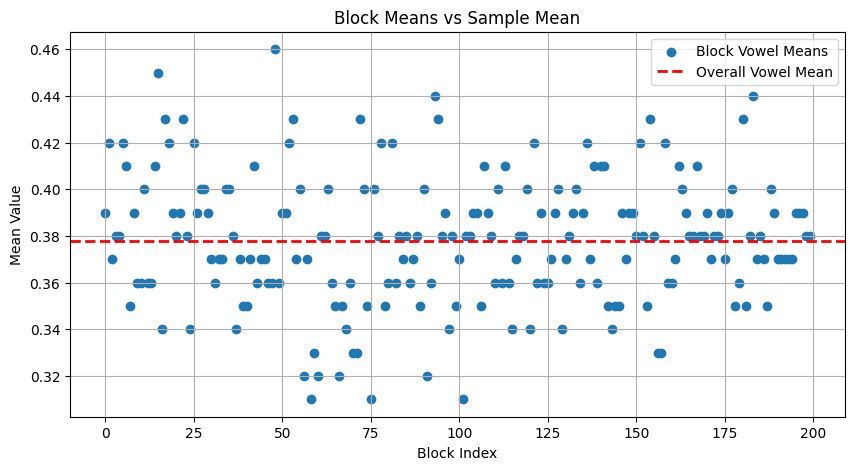

Number of vowels(v)     :  7560
Number of consonants(c) :  12440


In [8]:
block_length = 100
block_prob_v = []
for i in range(0,len(text_20k_vc),block_length):
    block = text_20k_vc[i:i+block_length]
    block_prob_v.append(block.count("v")/len(block))
mean_v = text_20k_vc.count("v")/len(text_20k_vc)

plt.figure(figsize=(10, 5))

plt.scatter(range(len(block_prob_v)), block_prob_v, label="Block Vowel Means")
plt.axhline(mean_v, color='red', linestyle='--', linewidth=2, label="Overall Vowel Mean")

plt.xlabel("Block Index")
plt.ylabel("Mean Value")
plt.title("Block Means vs Sample Mean")
plt.legend()
plt.grid(True)

plt.show()
print("Number of vowels(v)     : ",text_20k_vc.count("v"))
print("Number of consonants(c) : ",text_20k_vc.count("c"))

The plot above shows the mean vowel % for the entire sample (red dashed line) and those for each of the individual 100-character blocks. The sample has 37.8% vowels. This is lower than the 43.2% observed by Markov. Baring any errors above, this could be due to difference in language and/or how the texts were preprocessed. 

For part 2, we will track the counts for each combination of vowels and consonants, along with the expected counts and proportions assuming independence of characters in each pair. 

In [9]:
pairs = {"vv":0, "vc":0, "cv":0, "cc":0}

# Loop through adjacent pairs
for i in range(len(text_20k_vc)-1):
    pair = text_20k_vc[i:i+2]
    if pair in pairs:
        pairs[pair] += 1

# Calculate proportions
total_pairs = sum(pairs.values())
proportions = {k: v/total_pairs for k,v in pairs.items()}

expected_proportions = {"vv":mean_v*mean_v, "vc":mean_v*(1-mean_v), "cv":(1-mean_v)*(mean_v), "cc": (1-mean_v)*(1-mean_v)}
expected_counts = {}
for i,v in expected_proportions.items():
    expected_counts[i] = int(v*19999)

df = pd.DataFrame({'Counts': pairs, 'Proportions': proportions,'Expected Counts': expected_counts, 
                   'Expected proportions': expected_proportions })
df

,Counts,Proportions,Expected Counts,Expected proportions
vv,1229,0.061453,2857,0.142884
vc,6331,0.316566,4702,0.235116
cv,6331,0.316566,4702,0.235116
cc,6108,0.305415,7737,0.386884


We observe 1229 double vowel pairs (6.1% of all pairs). If the vowels were independent, then the expected proportion of 2 vowel pairs will be (0.378)x(0.378) = 0.143 i.e 14.3%. In the 19999 possible pairs of 20000 characters, we would expect to see 0.143x19999 or about 2857 vowel pairs. We observe only 1229. We observe similar disparities in the proportions for the remaining pairs. For e.g. we observe much higher proportions of vowel-consonant sequences than would have been predicted were they independent. This suggests that the sequence of letters in the text are not independent. 

We have reached similar conclusions to Markov, with less than 100 lines of code that allows us to escape the tedium of doing all this by hand, as Markov had laboriously done over a century ago.

## Hidden Markov Models

Hidden Markov Models (HMMs) are a type of Markov Models where the states are hidden, and all we see are observations (sometimes referred to as emissions), based on which we can try to infer the hidden states. Using our workout-tracking example from before, for each day I have a cross (X) in our planner for when I am active, and a blank (O) for when I am inactive. In explaining Markov chains, we had used 'active' and 'inactive' as our states. Now, let's suppose that whether I am active or inactive on any given day depends on an underlying process, say the weather. If the weather is sunny then I am 90% likely to be active. If it is cloudy, then I am 50% likely to be active, and if it is rainy then I am 10% likely to be active. In an HMM formulation of this problem, we would seek to model the underlying process of the weather on any given day and the transitions in weather from one day to another between the states of 'sunny', 'cloudy' and 'rainy'. However, we don't know what the weather is like on any given day. All we observe is whether I was active or not. Hence the weather on each day i.e. 'sunny', 'cloudy' and 'rainy' are referred to as hidden states. A visual representation of this example is shown below

```{figure} ../../images/hmm_example_small.png
---
width: 600px
name: hmm-example
---
Example of a Hidden Markov Model (HMM) with the states in circles, and the observation probabilities in a table next to it
```

An HMM is characterized by the following parameters [^3]:
* **N**: the number of states in the model (in our example, we have 3 different states i.e. types of weather - rainy, cloudy, and sunny). The individual states are labeled as $\{1,2,..,N\}$ with the state at time $t$ being denoted by $q_t$
* **M**: the number of distinct observation symbols per state (in our example, we have 2 distinct observation symbols - active and inactive). We denote the individual symbols as $V = \{v_1, v_2,...,v_M\}$
* **A**: the state transition probability distribution, i.e. $A=\{a_{ij}\}$ where $a_{ij} = P[q_{t+1} = j|q_t = i]$, $1{\le}i,j{\le}N$ (in our example, this represents the transitions between the states of 'sunny', 'cloudy' and 'rainy' from one day to another)
* **B**: the observation symbol probability distribution, i.e. $B=\{b_j(k)\}$ where $b_j(k)=P[o_t=v_k|q_t=j]$, $ 1{\le}k{\le}M$ (in our example, this will be the likelihood, say, of being active, given that the weather is sunny)
* **${\pi}$**: the initial state distribution, $\pi = \{\pi_i\}$ where $\pi_i = P[q_1=i]$, $1{\le}i{\le}N$ (in our example this is the probability of the initial state being 'sunny', 'cloudy' or 'rainy')

Since $A$,$B$ and $\pi$ encapsulate the values of N and M, we use the notation $\lambda=(A,B,\pi)$ to refer to the complete parameter set of the model. Once these parameters are specified, we can use it to generate a sequence. We will do so for our example. 

[^3]: The characterization below comes from Chapter 6 of Larry Rabiner's textbook [Fundamentals of Speech Recognition](https://www.amazon.com/Fundamentals-Speech-Recognition-Lawrence-Rabiner/dp/0130151572), which is similar to his highly cited paper [A Tutorial on Hidden Markov Models and
Selected Applications in Speech Recognition](https://www.cs.cmu.edu/~cga/behavior/rabiner1.pdf). I have borrowed generously from the chapter for this section; the example is my own. As a personal anecdote, I was fortunate to take Prof. Rabiner's course on Speech Recognition at UCSB, where he would review each of our Matlab code printouts, adding comments suggesting improvements and on occasion, calling out a function or approach we had used that he found interesting or insightful.

We specify the state transition probabities $A$ as below

In [10]:
# Specify the parameters of the HMM
states = ['sunny','cloudy','rainy']
# State transition probability
A = [[0.7, 0.2, 0.1],
     [0.2, 0.5, 0.3],
     [0.2, 0.3, 0.5]]
A = pd.DataFrame(A,index=states, columns=states)
A

,sunny,cloudy,rainy
sunny,0.7,0.2,0.1
cloudy,0.2,0.5,0.3
rainy,0.2,0.3,0.5


The observation symbol probability $B$ for each state is given below

In [11]:
obs = ['active','inactive']
B = [[0.9,0.1],
     [0.5,0.5],
     [0.1,0.9]]
B = pd.DataFrame(B, index=states, columns=obs)
B

,active,inactive
sunny,0.9,0.1
cloudy,0.5,0.5
rainy,0.1,0.9


Finally, the initial state distribution is specified below

In [12]:
pi = [[0.3],[0.4],[0.3]]
pi = pd.DataFrame(pi,index=states, columns=['pi'])
pi

,pi
sunny,0.3
cloudy,0.4
rainy,0.3


Now that we have the parameter set for the model, we are ready to generate a sequence of observations. We do so as follows:
1. We start by picking an initial state based on the initial state distribution $\pi$.
2. We set the time $t=1$
3. Next we pick an observation based on the observation symbol probability for that state in $B$. This is our observation for time $t$.
4. Now, we transition to the next state using the state transition probability $A$
5. We increment our time $t=t+1$ and return to step 3 if $t<T$, otherwise stop
6. We repeat steps 2

We will generate a sequence of length 8 (i.e. T=8) for ease of display below

In [13]:
import random
random.seed(25)

def generate_hmm_sequence(A,B,p,num_steps):
    states = B.index.values.tolist()
    obs = B.columns.values.tolist()
    init_state = random.choices(states, weights=p.values, k=1)[0]
    current_state = init_state
    sequence = []
    for _ in range(num_steps):
        # Get observation probabilities for the current state
        obs_prob = [B.loc[current_state][o] for o in obs]
        # Pick an observation based on its obs. probability
        obs_value = random.choices(obs, weights=obs_prob, k=1)[0]
        sequence.append(obs_value)
        # Choose the next state based on the state transition probabilities
        probs = [A.loc[current_state][s] for s in states]
        next_state = random.choices(states, weights=probs, k=1)[0]
        # Update current state
        current_state=next_state
    return sequence

T = 8 # sequence length
generated_hmm_sequence = generate_hmm_sequence(A,B,pi,T)
print(generated_hmm_sequence)

['inactive', 'inactive', 'inactive', 'inactive', 'active', 'active', 'active', 'inactive']


Going from a model to a sequence is straightforward, however going from a sequence to a model is not. There are [3 basic problems](https://www.cs.cmu.edu/~cga/behavior/rabiner1.pdf) HMMs need to solve to be useful. 
1. Given the observation sequence $O$ and a model $\lambda$ how do we compute the probability that the sequence was produced by the model i.e. $P(O|\lambda)$?. This is referred to as the **evaluation problem** i.e. one of evaluating how well the model matches the observations.
2. Given the observation sequence $O$ and a model $\lambda$ how do we choose a corresponding state sequence $Q$ which best explains the observations? This problem looks to **uncover the hidden states** corresponding to the observations, given the model.
3. How do we adjust the model parameters $\lambda$ so as to best describe the observation sequence $O$ i.e. how do we maximize $P(O|\lambda)$? This is referred to as the **training problem** where we use the observation sequence to train an HMM model.

The evaluation problem can be solved by considering combinations of all possible states and calculating the likelihood of the observation given each state $P(O|Q,\lambda)$, and the probability of the state sequence given the model $P(Q|\lambda)$. Multiplying these two terms gives us $P(O,Q|\lambda)$ for each state sequence combination, and summing this over all possible state sequences gives us $P(O|\lambda)$. This approach is computationally complex. For N possible states and T time steps, we have $N^T$ possible state sequences for which we have to evaluate the likelihood of the observed values. For 5 states and 100 observations, we have $5^{100} = 7.8*10^{69}$ possible combinations. A less computationally intensive approach is to use the forward and backward procedure that works through each time step calculating probabilities and accumulating them. 

For solving the second problem of identifying the best hidden states that match the observations, one simple approach is to pick a state that maximizes the probability of the observation. In our example, if the observation sequence we are given is $[inactive,active,inactive]$, then looking at the observation symbol probabulity $B$, we see that 'inactive' has the highest probability in state 'rainy' and 'active' has the highest probability in state 'sunny'. So one guess for the states corresponding to the sequence of observations is $[rainy,sunny,rainy]$. One of the shortcomings is that it does not account for state transitions. For e.g. if the transition probability going from 'rainy' to 'sunny' were 0, the above sequence of states would not be valid. A better approach is the [Viterbi algorithm](https://viterbischool.usc.edu/news/2017/03/viterbi-algorithm-demystified/) that tracks the state with the best 'score' in each time step, uses the score in getting the best state and score in the next time step and so on. After the final time step, we have a sequence of states with the best score along each step in the sequence. The score accounts for transtion probabilities, avoiding the caveat in the prior approach. 

The solution to the third problem, one of training the HMM, requires us to start with an initial model $\lambda$ and then iteratively re-estimate the parameters using the Baum-Welch Method (a form of expectation-maximization), to come up with an updated model $\bar{\lambda}$ such that $P(O|\bar{\lambda})>P(O|{\lambda})$. The method uses the forward and backward procedure referenced in the solution to the evaluation problem. 

**Applications**

HMMs have been used extensively in [speech recgonition](https://www.cs.cmu.edu/~cga/behavior/rabiner1.pdf). An example is training an HMM for each word in a vocabulary where the states can be the number of phonemes in the world, and the training data involves utterances of the word by different speakers. If there are 100 words in the vocabulary, this would involve 100 different HMM models. At inference time, an observed speech signal $O$ is evaluated against the HMM for each word in the vocabulary $P(O|{\lambda}^i)$, and the model that has the highest probability of generating the signal is identified. The word associated with the model is output as the recognized word. Other applications include [computational biology](https://genome.crg.es/courses/cshl2007/T5b/2004EddyMarkov.pdf), [finance](https://pdfs.semanticscholar.org/bc80/6ca12b65abf8b47d464baa80b76c6a20a5a1.pdf), and [robotics](https://webprod.uhv.edu/gaming/publications/Tav-08-UnderstandIntent-ICHRI.pdf).

## Markov Decision Process

A Markov Decision Process (MDP) introduces the concept of actions and rewards to the standard Markov model. At each time step, a decision maker (i.e. agent) finds itself in a certain state, based on which it selects an action. As a consequence of the action, the agent receives a reward, and finds itself in a new state. The transition probabilities depend on the prior state and action, as do the rewards. The set of unique states characterize the environment in which the agent operates. The states satisfy the Markov property, in that the transition to a given state depends only on the prior state and action, with the prior state assumed to include all information on past agent-environment interactions. 

To illustrate an MDP, we will work with a variation of our activity example. Let's suppose that being active or inactive are actions I take based on my health. If I am healthy, I can choose to be active (for which I get a positive reward $R$), or inactive (for which I get a small reward for being healthy $0.25R$). In being active, there is a small probability $\alpha$ that I may get injured. In the injured state, the only possible action is being inactive (i.e. resting), with a probability $\beta$ I may return to the healthy state, and a probability $1-\beta$ where I stay in the injured state. For each day in the injured state, I receive a negative reward ($-2R$). The set of start states, actions, end states, transition probabilities, and rewards are shown below. The notation $s$ refers to the current state, $a$ to the action taken from the current state, $s'$ to the next state, $p(s'|s,a)$ to the state transition probability to the next state given the current state and action, and $r(s,a,s')$ to the reward associated with the current state, action, and next state.[^4]

[^4]: The primary reference for MDP (specificlly finite MDP) is <i>Chapter 3: Finite Markov Decision Processes</i> in the book [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) by Sutton and Barto. 

| s | a | s' | p(s'\|s,a) | r(s,a,s') |
|---|---|---|--|--|
| healthy | active   | healthy  |  $1-\alpha$ | R    |
| healthy | active   | injured  |  $\alpha$   | -R   | 
| healthy | inactive | healthy  |  1          | 0.25R   |
| healthy | inactive | injured  |  0          | 0   |
| injured | inactive | injured  |  $1-\beta$  | -2R |
| injured | inactive | healthy  |  $\beta$    | 0   |

An illustration of the MDP process with states, actions and transition probabilities and rewards is shown below

```{figure} ../../images/mdp_example_small.png
---
width: 600px
name: mdp-example
---
Example of the Markov Decision Process (MDP) with actions in blue and the (probability, reward) specified along each transition
```

Our goal in the MDP process is to take actions starting from an initial state that maximizes our total reward. We do so by navigating these loops (or rather specifying a simulation with an agent that navigates these loops) so that we can learn the optimal **policy** i.e. the action we need to take in each state to maximize our rewards. 

MDPs are an integral part of reinforcement learning (RL), and therefore play a role in the development of large language models (LLMs) where RL is used to improve the fine-tuning and reasoning capabilities of LLMs. They have also been applied to [medical decision making](https://pmc.ncbi.nlm.nih.gov/articles/PMC3060044/pdf/nihms-274821.pdf) and [finance](https://arxiv.org/pdf/2112.04553), among others.

MDP and HMMs come together in Partially Observable Markov Decision Process (POMDP) which is like an MDP with rewards and actions, except the states are hidden, and we only have observations emitted by the states, much like what we have seen in HMMs. A grid explaining the distinction is shown below [^5]

```{figure} ../../images/littman_grid_small.png
---
width: 800px|
name: littman-grid
---
Distinction between the different types of Markov Models
```
A detailed list of applications for POMDP can be found in [this survey by Anthony Cassandra](https://www.cassandra.org/arc/papers/applications.pdf). 
[^5]: attributed to [Michael Littman](https://www.littmania.com/)

## Wrap-up

Markov models span over a 100 year timeline starting with A. A. Markov's first paper in 1906 to settle a mathematical (and possibly theological) score with a rival, to its varied manifestations and wide use today across technology, medicine, finance and society. Markov's application of his chained probabilities to the text of Eugene Onegin stands as a precursor to its subsequent use in speech and language modeling, most recently in the refinement of large language models (LLMs) using reinforcement learning. 

A quick note on references: I have linked to relevant papers and texts where I have mentioned them. There are a few that bear a particular mention. [Brian Hayes](https://www.americanscientist.org/author/brian_hayes) article titled [First Links in the Markov Chain](https://www.americanscientist.org/article/first-links-in-the-markov-chain) in the March-April 2013 issue of American Scientist is an excellent introduction to Markov Chains and its history. [The Life and Work of A.A. Markov](https://www.ece.ufl.edu/wp-content/uploads/sites/77/archive/spm_files/Markov-Work-and-life.pdf) by Basharin, Langville, and Naumov presents a detailed biography of A. A. Markov, as does [Markov and the Birth of Chain Dependence Theory](https://www.landsburg.org/markov2.pdf) by E. Seneta, which further delves into the mathematical details of Markov's 1906 paper. A description to Hidden Markov Models (HMM) would be incomplete without a reference to [A tutorial on Hidden Markov Models and Selected Applications in Speech Recognition](https://www.cs.cmu.edu/~cga/behavior/rabiner1.pdf) by L. Rabiner. 